In [73]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_test.csv
/kaggle/input/fashionmnist/fashion-mnist_train.csv
/kaggle/input/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/fashionmnist/train-images-idx3-ubyte


In [74]:
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout,Flatten,Reshape,Conv2DTranspose,Input,Conv2D, LeakyReLU
from tensorflow.keras.models import Sequential
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [75]:
df=pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_train.csv").iloc[:,1:]
df.shape

(60000, 784)

In [76]:
batch_size = 32
codings_size = 100
n_epochs = 10

In [77]:
dataset = tf.data.Dataset.from_tensor_slices(df.values)
dataset = dataset.map(lambda x: tf.reshape(x, (28, 28, 1)))
dataset = dataset.map(lambda x: tf.cast(x, tf.float32))
dataset = dataset.map(lambda x: (x / 127.5) - 1.0)
dataset = (
    dataset
    .shuffle(1000)
    .batch(batch_size, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

In [78]:
generator = Sequential([
    Input(shape=(codings_size,)),
    Dense(7 * 7 * 128),
    BatchNormalization(),
    Reshape((7, 7, 128)),
    Conv2DTranspose(64, kernel_size=5, strides=2, padding="same",activation="selu"),
    BatchNormalization(),
    Conv2DTranspose(1, kernel_size=5, strides=2,
                    padding="same", activation="tanh"),
])


In [79]:
discriminator = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(64, kernel_size=5, strides=2, padding="same"),
    LeakyReLU(0.2),
    Dropout(0.4),

    Conv2D(128, kernel_size=5, strides=2, padding="same"),
    LeakyReLU(0.2),
    Dropout(0.4),

    Flatten(),
    Dense(1, activation="sigmoid"),
])

In [80]:
discriminator.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy"
)


In [81]:
discriminator.trainable = False

In [82]:
gan = Sequential([
    generator,
    discriminator
])

In [83]:
gan.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy"
)

In [84]:
def plot_compared_generated_real_images(generator, noise_dim, n=16):

    noise = tf.random.normal([n, noise_dim])
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(2 * n, 4))
    
    for i in range(n):

        plt.subplot(2, n, i + 1)
        plt.imshow(df.iloc[i].to_numpy().reshape(28, 28), cmap="binary")
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(generated_images[i], cmap="binary")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [85]:
def train_gan(gan, dataset, batch_size, coding_size, n_epochs):
    generator, discriminator = gan.layers

    for epoch in range(n_epochs):
        print("epoch : "+str(epoch+1)+" number of epochs : "+str(n_epochs))
        for x_batch in dataset:
            x_batch = tf.cast(x_batch, tf.float32)

            noise = tf.random.normal([batch_size, coding_size])
            generated_images = generator(noise)

            x_fake_and_real = tf.concat([generated_images, x_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size, dtype=tf.float32)

            discriminator.trainable = True
            discriminator.train_on_batch(x_fake_and_real, y1)

            noise = tf.random.normal([batch_size, coding_size])
            y2 = tf.constant([[1.]] * batch_size, dtype=tf.float32)

            discriminator.trainable = False
            gan.train_on_batch(noise, y2)

    plot_compared_generated_real_images(generator, coding_size)

epoch : 1 number of epochs : 10
epoch : 2 number of epochs : 10
epoch : 3 number of epochs : 10
epoch : 4 number of epochs : 10
epoch : 5 number of epochs : 10
epoch : 6 number of epochs : 10
epoch : 7 number of epochs : 10
epoch : 8 number of epochs : 10
epoch : 9 number of epochs : 10
epoch : 10 number of epochs : 10


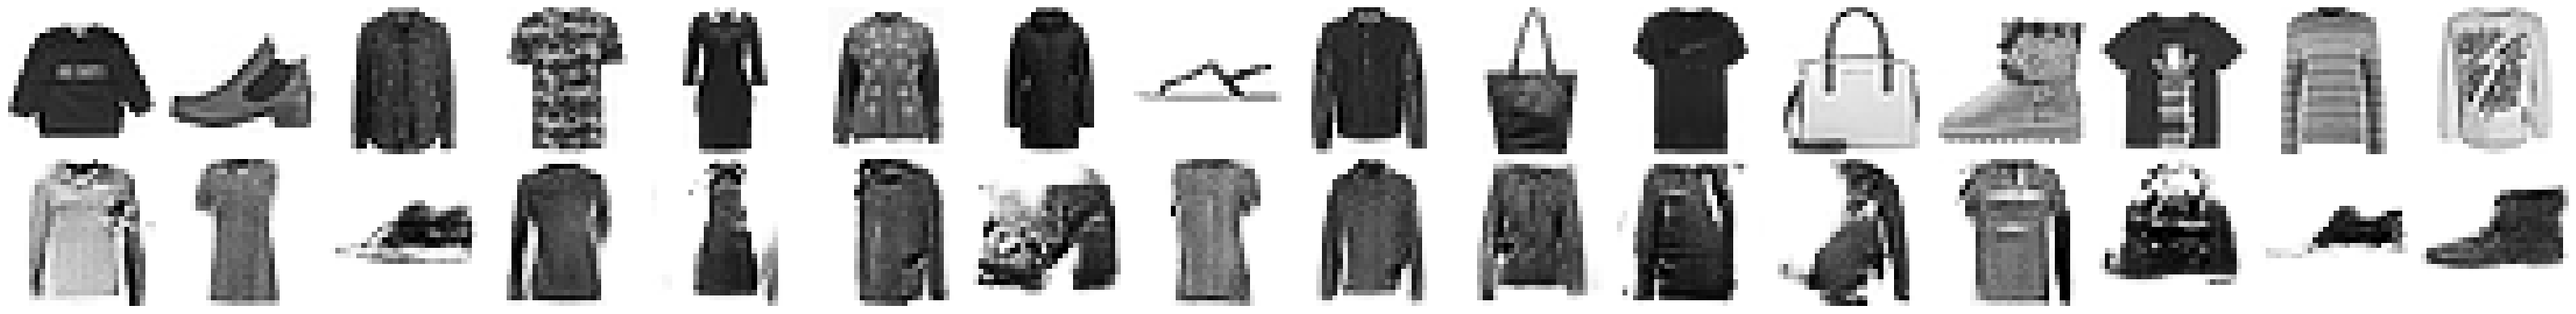

In [86]:
train_gan(gan, dataset, batch_size, codings_size, n_epochs)

In [87]:
def predict_gan(generator, coding_size, n_images=16):
    noise = tf.random.normal([n_images, coding_size])
    generated = generator(noise, training=False)

    plot_compared_generated_real_images(generator, coding_size)


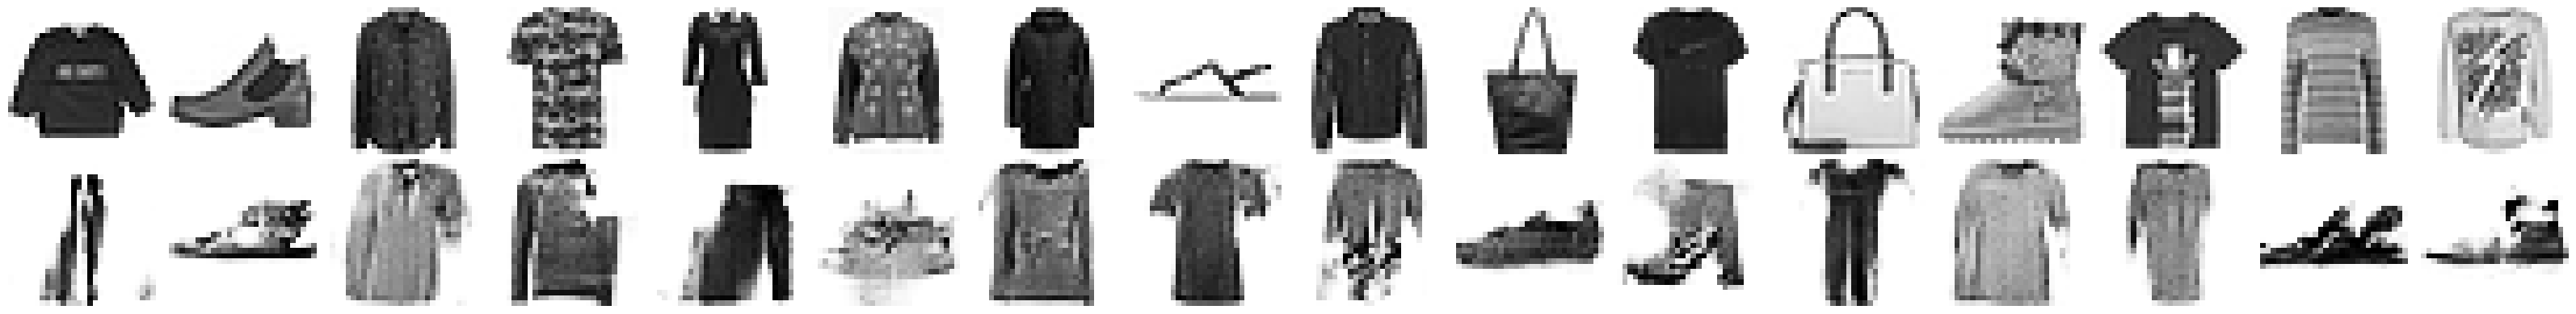

In [88]:
predict_gan(generator, codings_size, n_images=8)